In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
df = pd.read_csv('master_dataset_cleaned.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,1042722433e7633a6a857a82dcb8d881,1,d94b74483f40a15c2f4678a59c429408,87142160b41353c4e5fca2360caf6f92,8/15/2017 16:30,10.0,15.10,21929d7523b4ca73af799eed3d218276,delivered,8/8/2017 16:26,...,RS,53266a0e7b0a61e8e41f4e71db335a89,89440.0,Irineopolis,SC,1.0,credit_card,2.0,25.10,4.0
1,4a1c3af89657b2177e85765d4390ef46,1,45faac1ea8c173bb8c3e6cf23f5aac4e,6d803cb79cc31c41c4c789a75933b3c7,4/8/2018 21:10,59.9,14.51,f03b4ce360b0d79f411799cf275fb9c3,delivered,4/2/2018 20:58,...,SP,8d56bc0ef587bcbabca776198885ea99,14806.0,Araraquara,SP,1.0,credit_card,2.0,148.82,5.0
2,d72a8a7f89ec91dd2f7d1436be8645a6,1,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,9/18/2017 11:04,89.9,16.26,080ea580ebf890d1b95afdb8d7a5297e,delivered,9/12/2017 10:45,...,SP,36ab56c6d620321e2acaeabd24cb76db,4208.0,Sao Paulo,SP,1.0,credit_card,2.0,106.16,1.0
3,707366aec5103380c9d2bc6e503d4f66,1,0aabfb375647d9738ad0f7b4ea3653b1,37515688008a7a40ac93e3b2e4ab203f,8/7/2017 21:55,19.9,11.85,4b44972085bda435123999dab7212346,delivered,8/1/2017 21:23,...,SP,b6d66f034c53af0aeaa276144f332291,2531.0,Sao Paulo,SP,1.0,credit_card,1.0,31.75,3.0
4,7775f1a362c378b553296a6ac824ad0e,1,49e142d8098b20ff2dc9ec73cdd5afec,8f119a0aee85c0c8fc534629734e94fd,10/26/2017 8:49,36.0,14.10,f65cf41dc7566470b447e365bf24e831,delivered,10/22/2017 8:40,...,SP,93338aa66ca9b0b58aa1dbd31080f158,32280.0,Contagem,MG,1.0,credit_card,3.0,50.10,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       5574 non-null   object 
 1   order_item_id                  5574 non-null   int64  
 2   product_id                     5574 non-null   object 
 3   seller_id                      5574 non-null   object 
 4   shipping_limit_date            5574 non-null   object 
 5   price                          5574 non-null   float64
 6   freight_value                  5574 non-null   float64
 7   customer_id                    5574 non-null   object 
 8   order_status                   5573 non-null   object 
 9   order_purchase_timestamp       5573 non-null   object 
 10  order_approved_at              5571 non-null   object 
 11  order_delivered_carrier_date   5573 non-null   object 
 12  order_delivered_customer_date  5573 non-null   o

In [ ]:
df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,customer_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score
count,5574.000000,5574.000000,5574.000000,5497.000000,5497.000000,5497.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5573.000000,5533.000000
mean,1.200215,83.751936,18.627187,48.903220,746.219574,2.195197,1852.685268,29.877265,16.081823,22.810515,23997.384891,34758.053472,1.095460,2.736408,132.415536,4.056208
std,0.696890,57.761440,11.795465,10.101329,614.764247,1.723392,3168.842125,16.107856,12.720325,11.691628,26971.784270,29756.292648,0.659463,2.577088,138.598973,1.356109
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,8.000000,1001.000000,1004.000000,1.000000,1.000000,0.000000,1.000000
25%,1.000000,38.900000,12.792500,42.000000,340.000000,1.000000,280.000000,18.000000,8.000000,15.000000,6730.000000,11250.000000,1.000000,1.000000,57.790000,4.000000
50%,1.000000,69.900000,16.120000,52.000000,577.000000,1.000000,650.000000,24.000000,13.000000,20.000000,13720.000000,24220.000000,1.000000,1.000000,100.000000,5.000000
75%,1.000000,117.990000,20.080000,57.000000,933.000000,3.000000,1700.000000,37.000000,20.000000,30.000000,26379.000000,57052.000000,1.000000,4.000000,165.700000,5.000000
max,14.000000,271.990000,178.330000,64.000000,3947.000000,17.000000,30000.000000,105.000000,105.000000,93.000000,99500.000000,99955.000000,14.000000,24.000000,2202.400000,5.000000


In [ ]:
df.shape

(5574, 34)

Convert Datetime

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

Datetime conversion was performed to enable time-based trend analysis and feature engineering.

Purchase Month

In [ ]:
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

Purchase Day

In [ ]:
df['purchase_day'] = df['order_purchase_timestamp'].dt.day_name()

Purchase Hour

In [ ]:
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

Total Cost

In [ ]:
df['total_cost'] = df['price'] + df['freight_value']

Distribution of Review Score

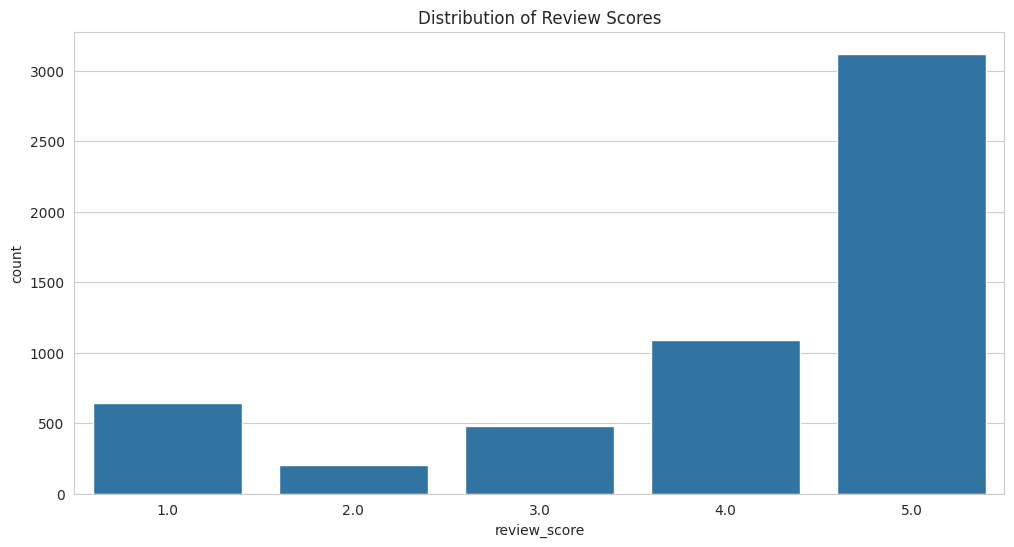

In [ ]:
sns.countplot(x='review_score', data=df)
plt.title('Distribution of Review Scores')
plt.show()

The distribution of review scores shows that most customers gave high ratings, especially a score of 5. This indicates that the majority of customers are satisfied with the e-commerce service. However, there are still some low ratings, which suggest that certain customers experienced issues with their shopping experience.

Distribution of Delivery Time

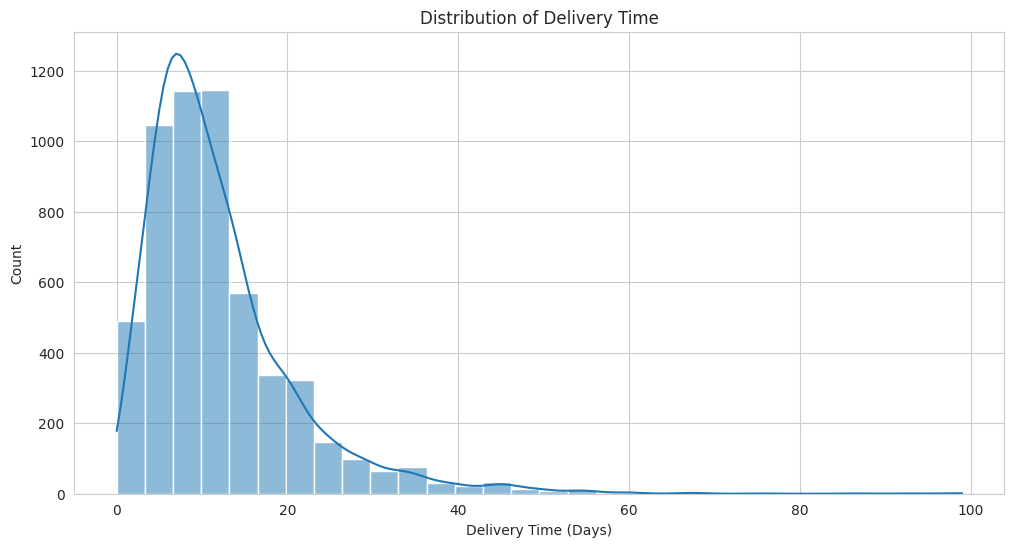

In [ ]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
sns.histplot(df['delivery_time'], bins=30, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.show()

The distribution of delivery time shows that most orders were delivered within a relatively short period. However, there are several outliers with extremely long delivery times, which may negatively affect customer satisfaction.

Delivery Time vs Review Score

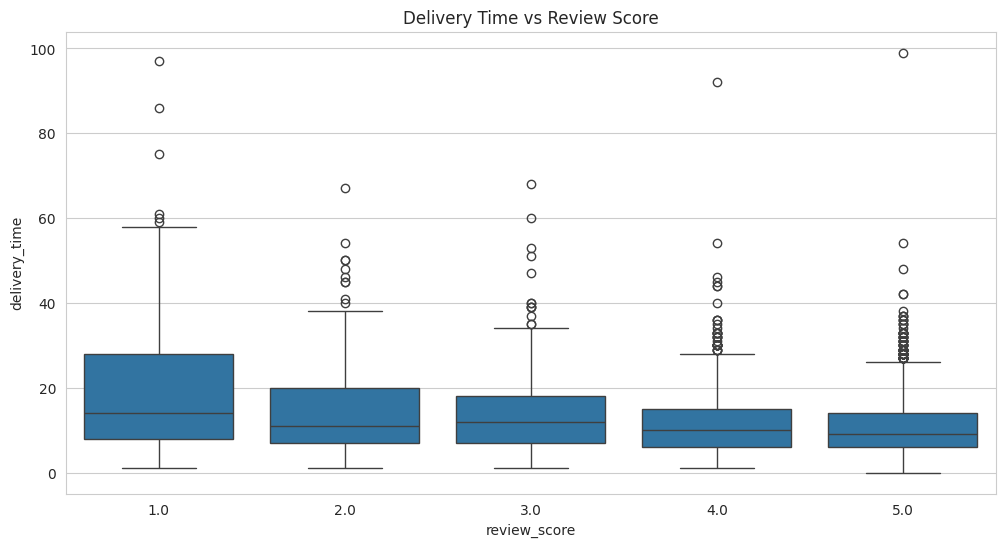

In [ ]:
sns.boxplot(x='review_score', y='delivery_time', data=df)
plt.title('Delivery Time vs Review Score')
plt.show()

The visualization indicates a negative relationship between delivery time and review score. Customers who received their orders faster tended to give higher ratings, while longer delivery times were associated with lower review scores.

Distribution of Payment Type

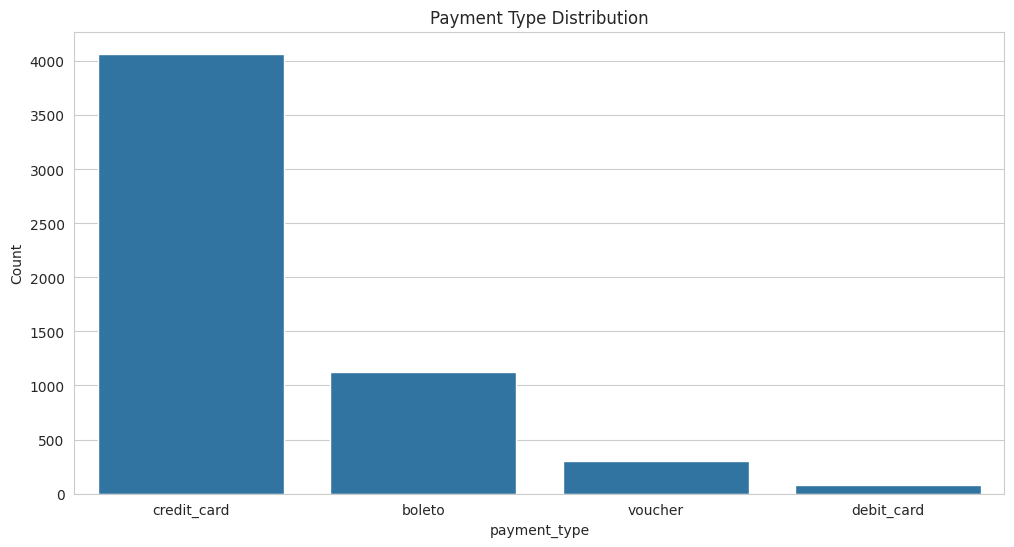

In [ ]:
payment_counts = df['payment_type'].value_counts()

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title('Payment Type Distribution')
plt.ylabel('Count')
plt.show()

Credit cards are the most dominant payment method used by customers. This indicates that customers prefer flexible and widely accepted payment methods for e-commerce transactions.

Review Score by Payment Type

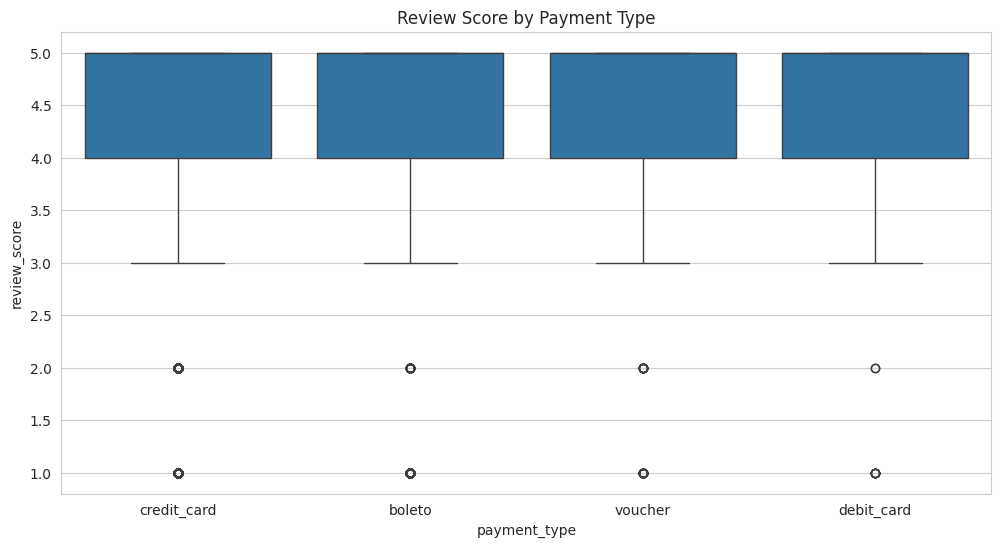

In [ ]:
sns.boxplot(
    x='payment_type',
    y='review_score',
    data=df
)

plt.title('Review Score by Payment Type')
plt.show()

The differences in review scores across payment methods are not very significant. This indicates that the payment method is not a major factor influencing customer satisfaction.

Top 10 Product Categories

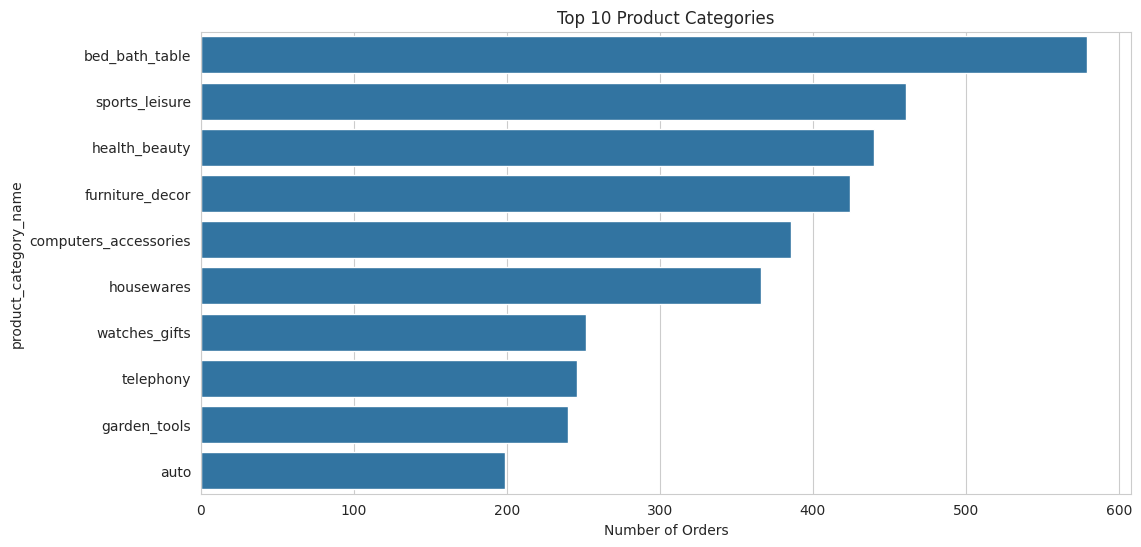

In [ ]:
top_category = df['product_category_name'].value_counts().head(10)

sns.barplot(
    x=top_category.values,
    y=top_category.index
)

plt.title('Top 10 Product Categories')
plt.xlabel('Number of Orders')
plt.show()

Several product categories have significantly higher transaction volumes compared to others. This indicates that customers have stronger preferences for certain product categories on the e-commerce platform.

Review Score by Product Category

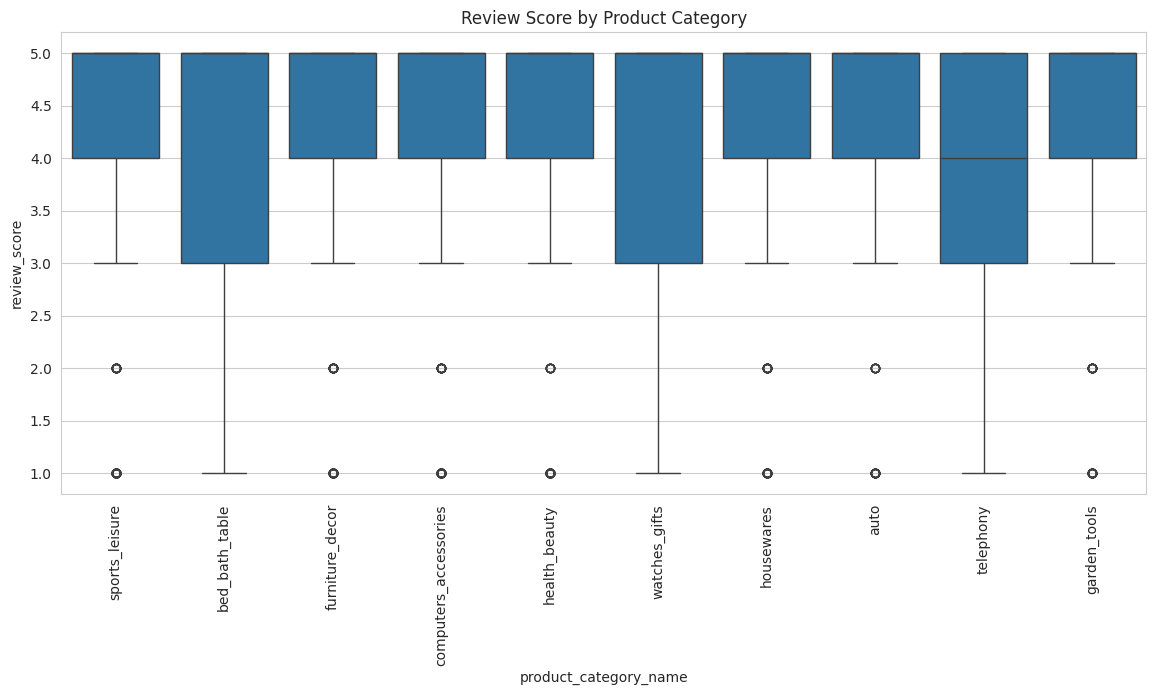

In [ ]:
top10 = df['product_category_name'].value_counts().head(10).index

filtered = df[df['product_category_name'].isin(top10)]

plt.figure(figsize=(14,6))

sns.boxplot(
    x='product_category_name',
    y='review_score',
    data=filtered
)

plt.xticks(rotation=90)
plt.title('Review Score by Product Category')
plt.show()

There are variations in review scores across product categories. Some categories show lower levels of customer satisfaction, which may indicate issues related to product quality, packaging, or delivery.

Revenue per Month

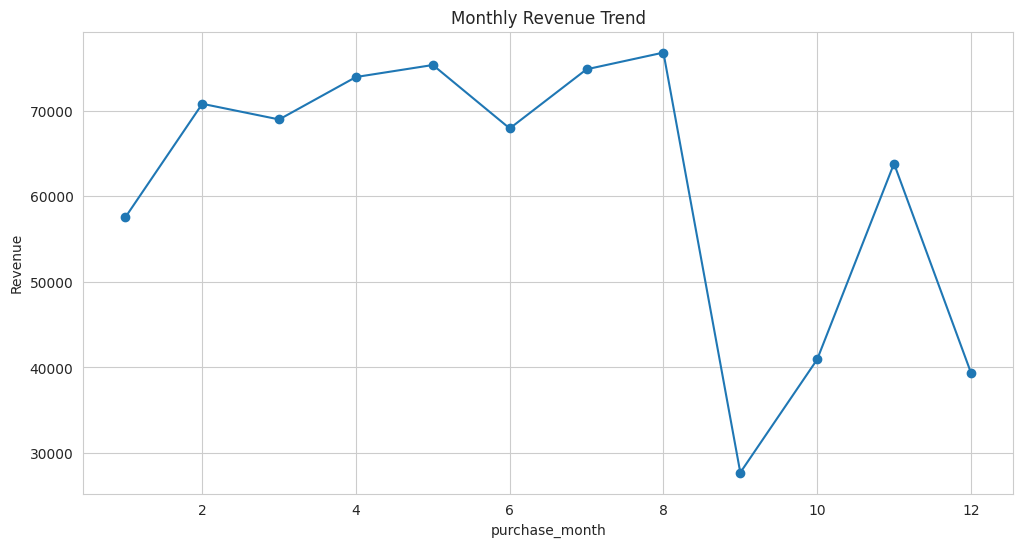

In [ ]:
monthly_sales = df.groupby('purchase_month')['payment_value'].sum()

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

Revenue fluctuated across different months, with some periods showing significant increases. This indicates the presence of seasonal patterns or higher purchasing activity during certain periods.

Freight Value Distribution

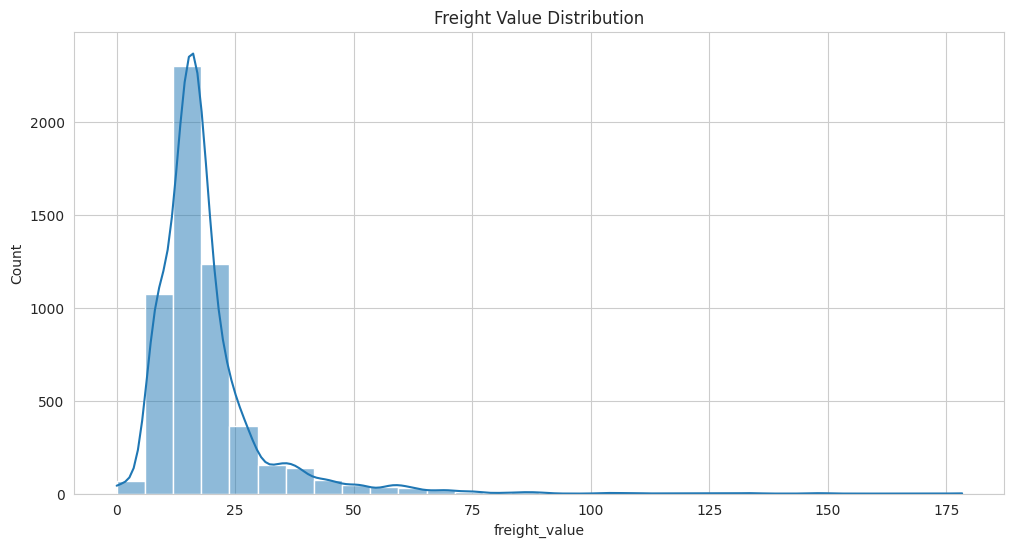

In [ ]:
sns.histplot(df['freight_value'], bins=30, kde=True)

plt.title('Freight Value Distribution')
plt.show()

Most transactions have relatively low freight values, although there are some transactions with very high shipping costs. This indicates variations in logistics costs based on location and product characteristics.

Freight Value vs Review Score

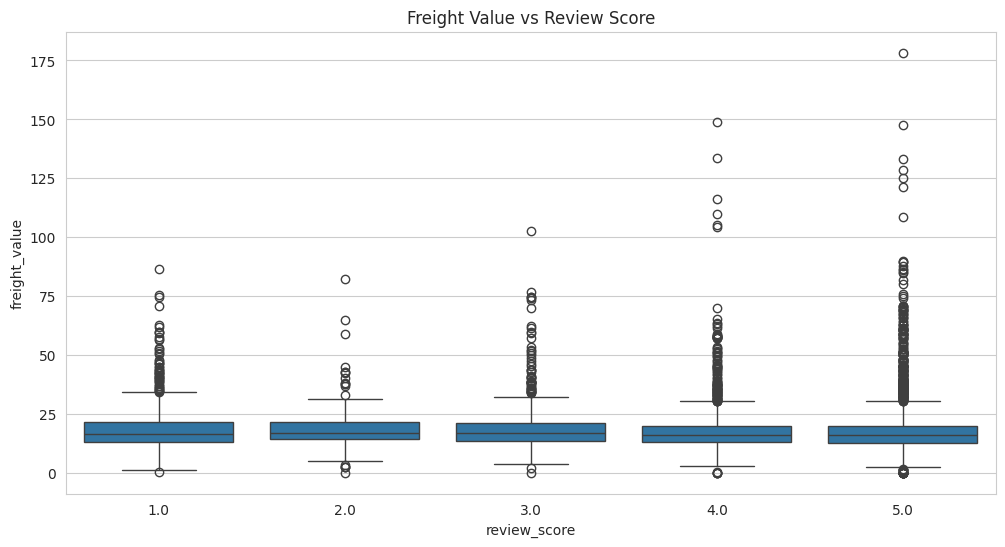

In [ ]:
sns.boxplot(
    x='review_score',
    y='freight_value',
    data=df
)

plt.title('Freight Value vs Review Score')
plt.show()

Higher freight values tend to be associated with slightly lower review scores. This suggests that shipping costs may influence customers’ perceptions of their shopping experience.

Correlation Heatmap

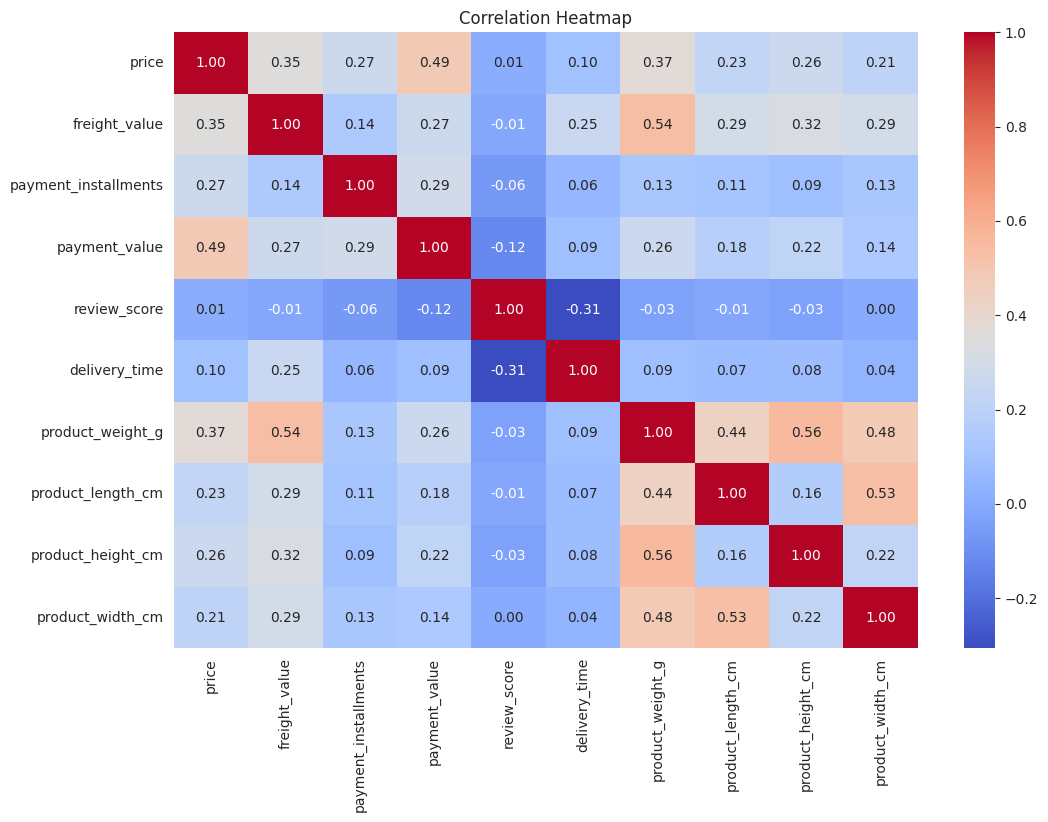

In [ ]:
numeric_cols = [
    'price',
    'freight_value',
    'payment_installments',
    'payment_value',
    'review_score',
    'delivery_time',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows that several variables have fairly strong relationships, particularly between payment_value and price. In addition, delivery_time has a negative relationship with review_score, which reinforces the previous analysis that delivery delays negatively impact customer satisfaction.

Top Customer State

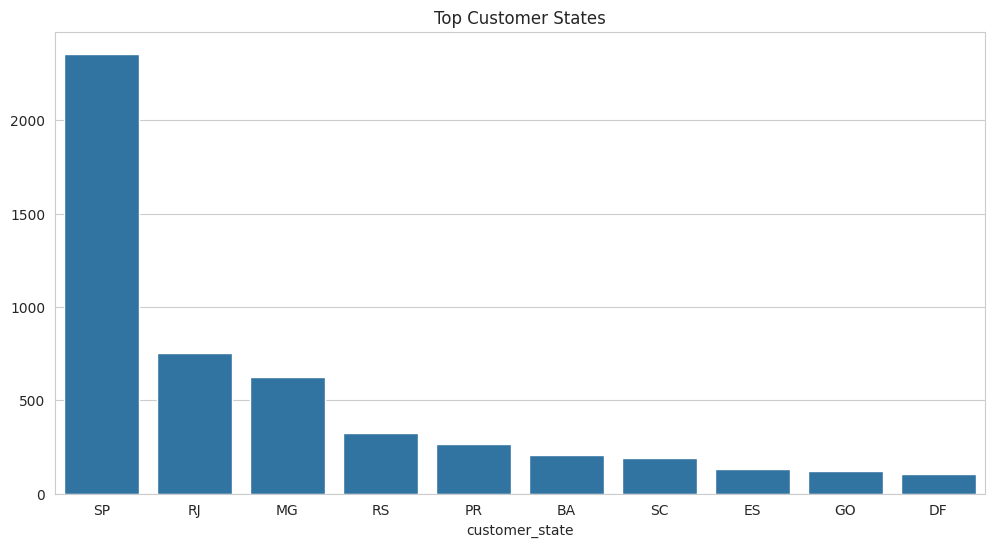

In [ ]:
top_states = df['customer_state'].value_counts().head(10)

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title('Top Customer States')
plt.show()

Most transactions originate from several specific states, indicating that customer activity is concentrated in regions with higher population density and economic activity.

Delivery Time by State

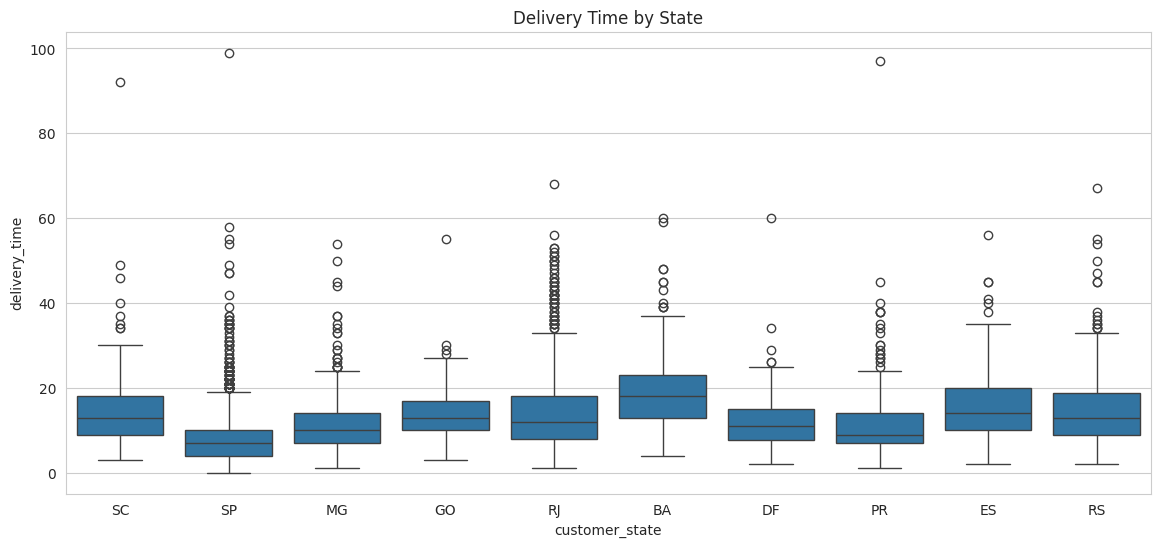

In [ ]:
top_states = df['customer_state'].value_counts().head(10).index

filtered = df[df['customer_state'].isin(top_states)]

plt.figure(figsize=(14,6))

sns.boxplot(
    x='customer_state',
    y='delivery_time',
    data=filtered
)

plt.title('Delivery Time by State')
plt.show()

There are differences in delivery times across states. Some regions show longer delivery times, which are likely influenced by geographical factors and the efficiency of logistics distribution.

Correlation Delivery Time vs Review Score

In [ ]:
corr = df['delivery_time'].corr(df['review_score'])

print(corr)

-0.30627344904351156


The negative correlation value indicates that the longer the delivery time, the lower the review score given by customers. This suggests that delivery speed is an important factor in customer satisfaction.

**Modelling**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Delivery Time

In [ ]:
df['delivery_time'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days

Estimated Delay

In [ ]:
df['estimated_delivery_time'] = (
    df['order_estimated_delivery_date']
    - df['order_purchase_timestamp']
).dt.days

Delivery Delay

In [ ]:
df['delivery_delay'] = (
    df['delivery_time']
    - df['estimated_delivery_time']
)

Feature and Target

In [ ]:
features = [
    'price',
    'freight_value',
    'payment_installments',
    'payment_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'delivery_time',
    'delivery_delay'
]

In [ ]:
target = 'review_score'

Data X and Y

In [ ]:
cols_to_check = features + [target]
df_cleaned = df.dropna(subset=cols_to_check)

X = df_cleaned[features]
y = df_cleaned[target]

Missing Value Check

In [ ]:
X.isnull().sum()

,0
price,0
freight_value,0
payment_installments,0
payment_value,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0
delivery_time,0
delivery_delay,0


Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Make Random Forest Model

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

Train Model

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Prediction

In [ ]:
predictions = model.predict(X_test)
predictions[:10]

array([4.34, 4.43, 4.58, 4.53, 3.83, 3.51, 4.1 , 4.36, 4.43, 3.57])

**Evaluation Metrics**

MAE (Mean Absolute Error)

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print('MAE:', mae)

MAE: 1.0089039445950017


RMSE

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print('RMSE:', rmse)

RMSE: 1.289975319298893


R² Score

In [ ]:
r2 = r2_score(y_test, predictions)

print('R² Score:', r2)

R² Score: 0.10492047766154688


Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
9        delivery_delay    0.231708
3         payment_value    0.144758
0                 price    0.114484
1         freight_value    0.103064
4      product_weight_g    0.085840
8         delivery_time    0.084692
6     product_height_cm    0.068632
5     product_length_cm    0.062631
7      product_width_cm    0.060656
2  payment_installments    0.043536


Feature Importance Visualization

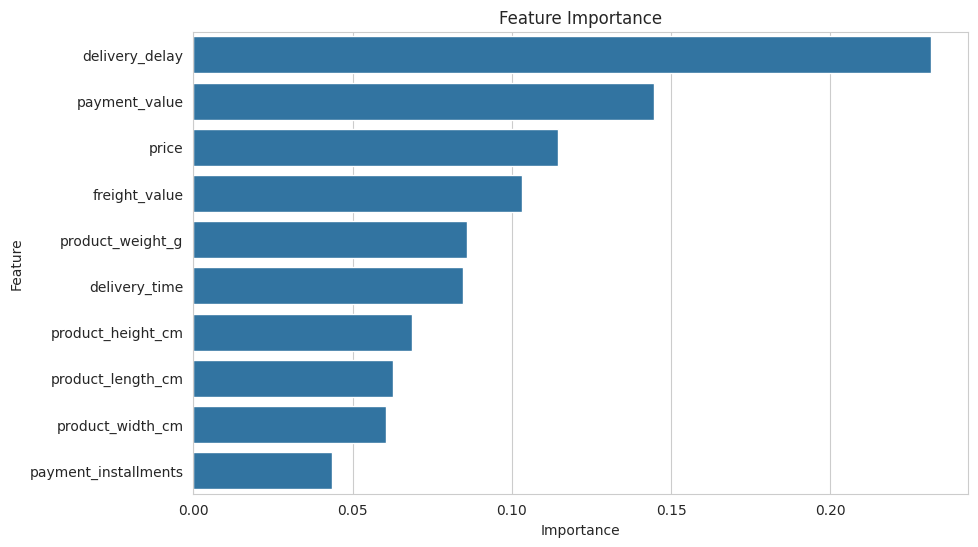

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

Feature importance analysis shows that delivery_time and delivery_delay are the most influential factors affecting review_score. This indicates that logistics performance has a significant impact on customer experience.

Model Result Visualization

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

comparison.head()

,Actual,Predicted
3398,4.0,4.34
4889,3.0,4.43
1829,5.0,4.58
5405,3.0,4.53
1728,4.0,3.83


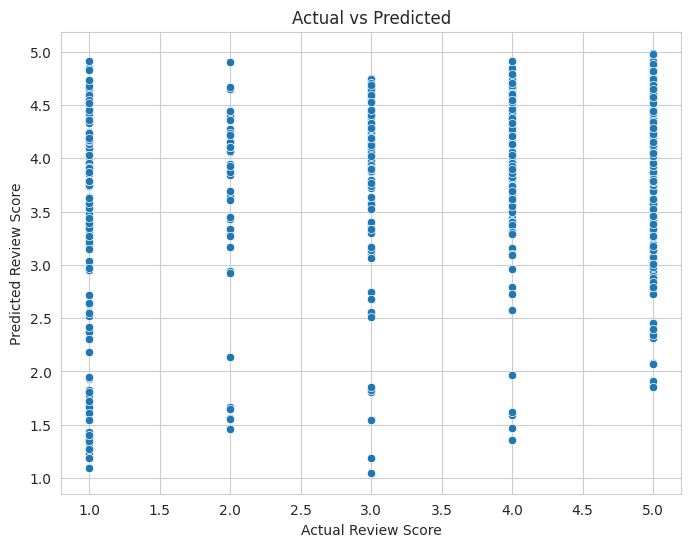

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel('Actual Review Score')
plt.ylabel('Predicted Review Score')

plt.title('Actual vs Predicted')

plt.show()

The scatterplot shows that the model’s predictions are fairly close to the actual values, although some deviations still exist. This indicates that the Random Forest Regression model has a reasonably good ability to predict review_score based on transaction and delivery features.

**Business Recommendations**

- The company should prioritize delivery optimization because delivery_time was identified as the most influential factor affecting customer satisfaction.
- Product categories with lower review scores should undergo quality evaluation and packaging improvements.
- Regions with consistently high delivery times may require logistics or warehouse optimization.

**Conclusion**

Based on the exploratory data analysis and Random Forest Regression modelling, several important patterns were identified within the e-commerce dataset. The analysis showed that delivery performance, especially delivery_time and delivery_delay, has a significant influence on customer satisfaction represented by review_score. Customers generally gave higher ratings for faster deliveries.

The modelling results also demonstrated that logistics-related factors are among the most influential variables affecting customer reviews. Overall, this project successfully transformed raw transactional data into meaningful insights and actionable recommendations that can support data-driven decision making in e-commerce operations.

**Limitations**

This project has several limitations. The dataset does not include external factors such as product quality, customer expectations, weather, or logistics infrastructure that may also influence customer satisfaction. In addition, the analysis mainly identifies correlations and predictive relationships, which do not necessarily represent direct causation. The model performance may also vary when applied to different or real-time datasets.

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
MAE  : 0.9764
RMSE : 1.2688
R²   : 0.1340


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [mae, xgb_mae],
    'RMSE': [rmse, xgb_rmse],
    'R2': [r2, xgb_r2]
})

comparison.sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2
1,XGBoost,0.976387,1.268846,0.134002
0,Random Forest,1.008904,1.289975,0.104920
